<a href="https://colab.research.google.com/github/rishi682/cset343/blob/main/AIH_Lab_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download(
    "andrewmvd/heart-failure-clinical-data"
)

print("Dataset path:", path)

import os

print("Files in dataset folder:")
print(os.listdir(path))

100%|██████████| 3.97k/3.97k [00:00<00:00, 2.83MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/andrewmvd/heart-failure-clinical-data/versions/1
Files in dataset folder:
['heart_failure_clinical_records_dataset.csv']


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# Find CSV file
csv_file = [
    os.path.join(path, file)
    for file in os.listdir(path)
    if file.endswith(".csv")
][0]

print("CSV file:", csv_file)

# Load dataset
df = pd.read_csv(csv_file)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset shape:", df.shape)

CSV file: /root/.cache/kagglehub/datasets/andrewmvd/heart-failure-clinical-data/versions/1/heart_failure_clinical_records_dataset.csv

First 5 rows:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1



Dataset shape: (299, 13)


In [ ]:
# ============================================================
# 3. SUMMARIZE DATASET
# ============================================================

print("========== DATASET SUMMARY ==========")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\n========== DATA TYPES ==========")

print(df.dtypes)

print("\n========== MISSING VALUES ==========")

print(df.isnull().sum())

print("\n========== DATASET INFORMATION ==========")

df.info()

========== DATASET SUMMARY ==========
Number of rows: 299
Number of columns: 13

========== DATA TYPES ==========
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

========== MISSING VALUES ==========
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_

In [ ]:
# ============================================================
# 4. INTRODUCE MISSING VALUES FOR DEMONSTRATION
# ============================================================

# Numerical missing values
df.loc[5, "age"] = np.nan
df.loc[15, "age"] = np.nan

df.loc[25, "serum_creatinine"] = np.nan
df.loc[35, "serum_creatinine"] = np.nan

df.loc[45, "ejection_fraction"] = np.nan
df.loc[55, "platelets"] = np.nan

# Categorical missing values
df.loc[65, "sex"] = np.nan
df.loc[75, "smoking"] = np.nan

print("Missing values after demonstration:")
print(df.isnull().sum())

Missing values after demonstration:
age                         2
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           1
high_blood_pressure         0
platelets                   1
serum_creatinine            2
serum_sodium                0
sex                         1
smoking                     1
time                        0
DEATH_EVENT                 0
dtype: int64


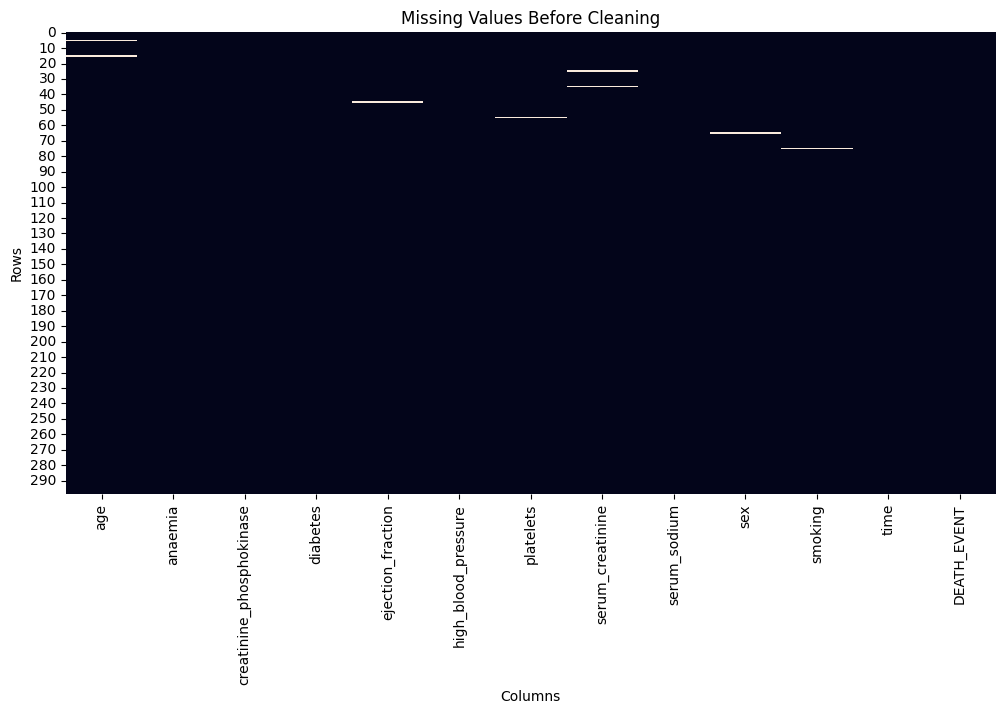

In [ ]:
# ============================================================
# MISSING VALUES HEATMAP
# ============================================================

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Before Cleaning")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

In [ ]:
# ============================================================
# 5. DISTRIBUTIONS BEFORE CLEANING
# ============================================================

numerical_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

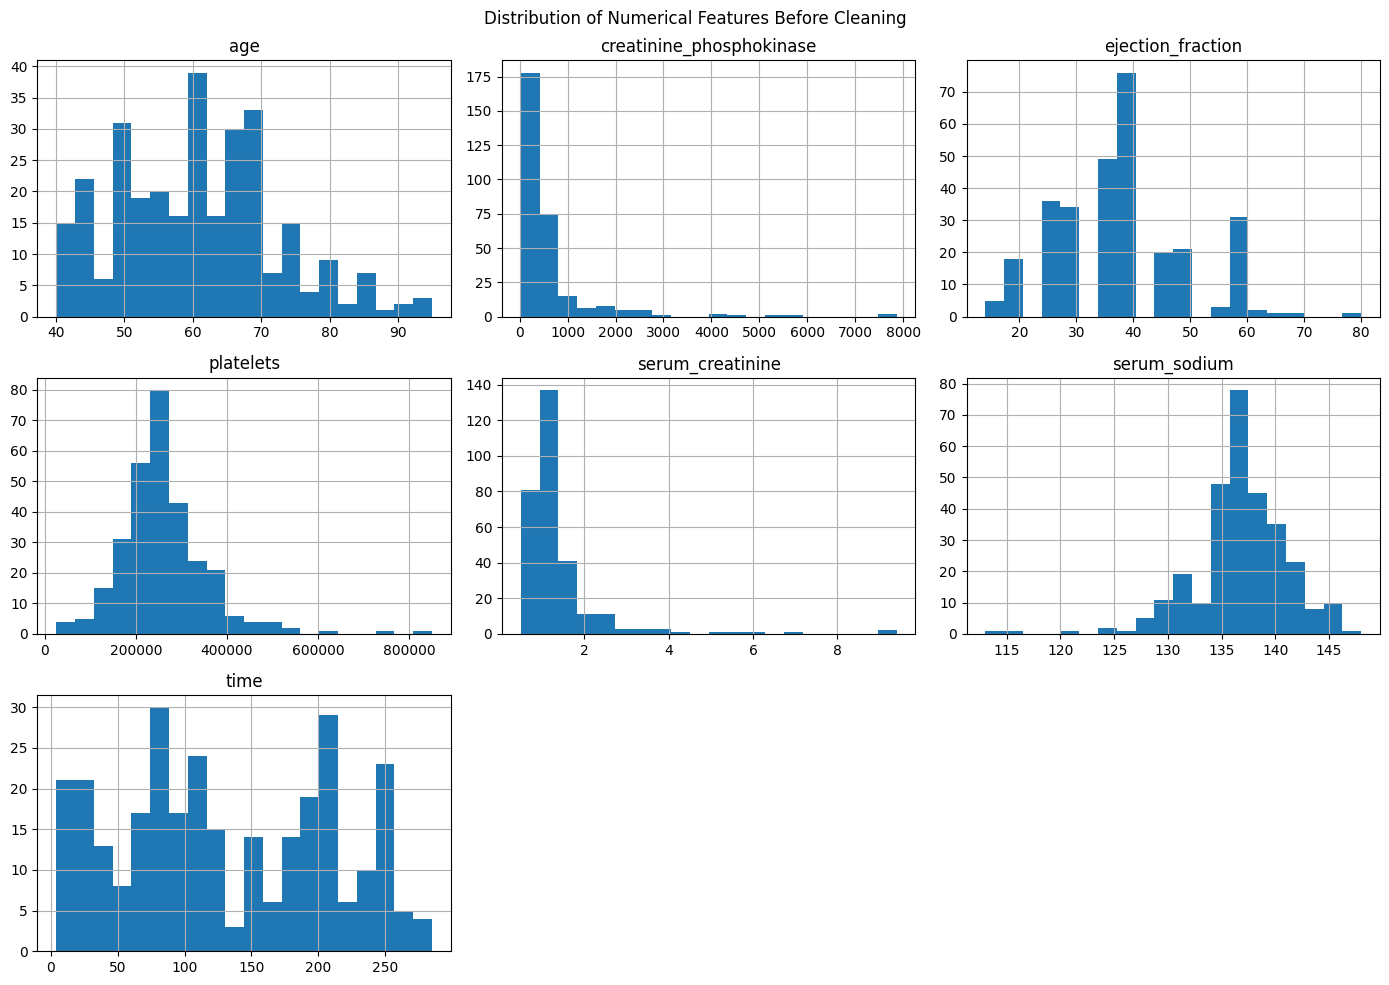

In [ ]:
df[numerical_columns].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features Before Cleaning"
)

plt.tight_layout()
plt.show()

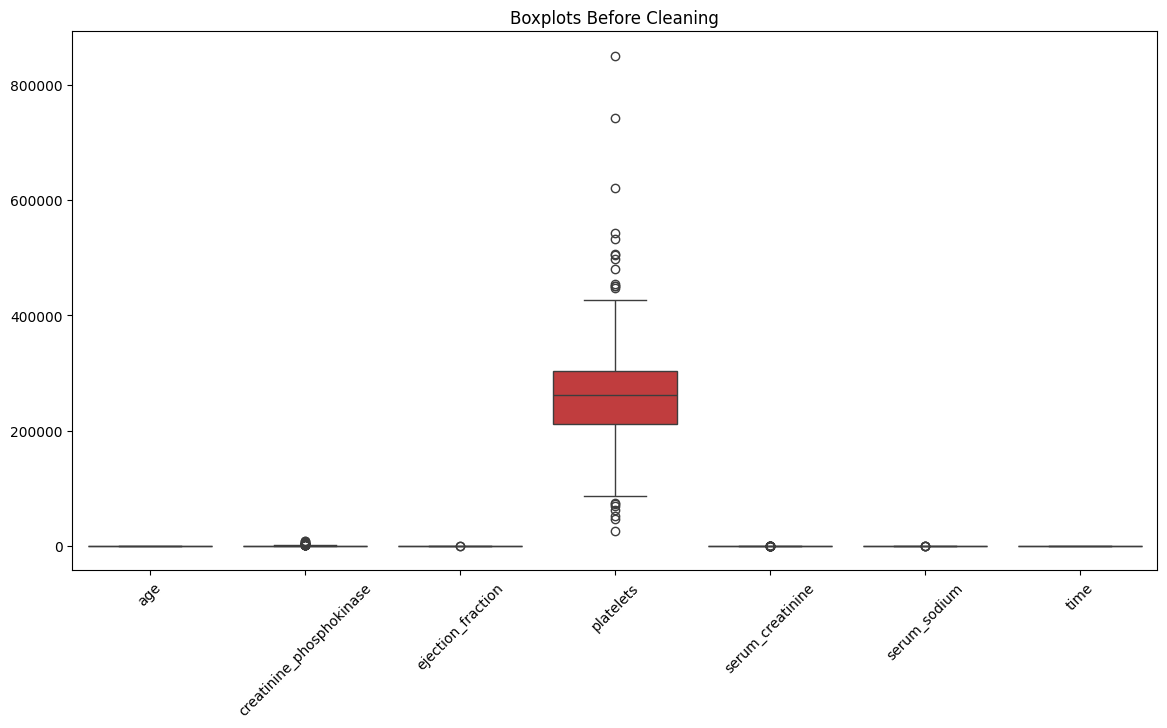

In [ ]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df[numerical_columns]
)

plt.title("Boxplots Before Cleaning")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# ============================================================
# 6. IMPUTE MISSING VALUES
# ============================================================

categorical_columns = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking"
]

print("========== BEFORE IMPUTATION ==========")
print(df.isnull().sum())


# Numerical features: median
for column in numerical_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )


# Categorical features: mode
for column in categorical_columns:
    df[column] = df[column].fillna(
        df[column].mode()[0]
    )


print("\n========== AFTER IMPUTATION ==========")
print(df.isnull().sum())

========== BEFORE IMPUTATION ==========
age                         2
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           1
high_blood_pressure         0
platelets                   1
serum_creatinine            2
serum_sodium                0
sex                         1
smoking                     1
time                        0
DEATH_EVENT                 0
dtype: int64

========== AFTER IMPUTATION ==========
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [ ]:
# ============================================================
# 7. REMOVE OUTLIERS USING IQR
# ============================================================

def remove_outliers_iqr(data, columns):

    cleaned_data = data.copy()

    for column in columns:

        Q1 = cleaned_data[column].quantile(0.25)
        Q3 = cleaned_data[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        cleaned_data = cleaned_data[
            (cleaned_data[column] >= lower_bound) &
            (cleaned_data[column] <= upper_bound)
        ]

    return cleaned_data


rows_before = len(df)

df = remove_outliers_iqr(
    df,
    numerical_columns
)

rows_after = len(df)

print("========== OUTLIER REMOVAL ==========")

print("Rows before removing outliers:", rows_before)
print("Rows after removing outliers:", rows_after)
print("Number of rows removed:", rows_before - rows_after)

========== OUTLIER REMOVAL ==========
Rows before removing outliers: 299
Rows after removing outliers: 226
Number of rows removed: 73


In [ ]:
# ============================================================
# 8. CHECK AND CORRECT INCONSISTENCIES
# ============================================================

print("========== INVALID VALUE CHECK ==========")

# Check negative age
negative_age = (df["age"] < 0).sum()

# Check invalid ejection fraction
invalid_ejection = (
    (df["ejection_fraction"] <= 0) |
    (df["ejection_fraction"] > 100)
).sum()

# Check invalid serum creatinine
invalid_creatinine = (
    df["serum_creatinine"] <= 0
).sum()

# Check invalid sodium
invalid_sodium = (
    df["serum_sodium"] <= 0
).sum()

print("Negative age values:", negative_age)
print("Invalid ejection fraction:", invalid_ejection)
print("Invalid serum creatinine:", invalid_creatinine)
print("Invalid serum sodium:", invalid_sodium)
# Correct negative age values

if negative_age > 0:

    df.loc[
        df["age"] < 0,
        "age"
    ] = df["age"].median()

print("\nInvalid values corrected where necessary.")

========== INVALID VALUE CHECK ==========
Negative age values: 0
Invalid ejection fraction: 0
Invalid serum creatinine: 0
Invalid serum sodium: 0

Invalid values corrected where necessary.


In [ ]:
# ============================================================
# 9. FEATURE ENGINEERING
# ============================================================

# Create age_group

df["age_group"] = np.select(
    [
        df["age"] < 40,
        df["age"] <= 60,
        df["age"] > 60
    ],
    [
        "<40",
        "40-60",
        ">60"
    ],
    default="Unknown"
)

print("========== AGE GROUP ==========")

display(
    df[
        ["age", "age_group"]
    ].head(10)
)

========== AGE GROUP ==========


,age,age_group
0,75.0,>60
2,65.0,>60
3,50.0,40-60
5,60.0,40-60
6,75.0,>60
8,65.0,>60
11,62.0,>60
12,45.0,40-60
13,50.0,40-60
14,49.0,40-60


In [ ]:
# ============================================================
# CREATE RISK SCORE
# ============================================================

ef_norm = (
    df["ejection_fraction"] -
    df["ejection_fraction"].min()
) / (
    df["ejection_fraction"].max() -
    df["ejection_fraction"].min()
)

creatinine_norm = (
    df["serum_creatinine"] -
    df["serum_creatinine"].min()
) / (
    df["serum_creatinine"].max() -
    df["serum_creatinine"].min()
)

# Higher value = higher risk
ef_risk = 1 - ef_norm

df["risk_score"] = (
    ef_risk * creatinine_norm
)

print("========== RISK SCORE ==========")

display(
    df[
        [
            "ejection_fraction",
            "serum_creatinine",
            "risk_score"
        ]
    ].head(10)
)

========== RISK SCORE ==========


,ejection_fraction,serum_creatinine,risk_score
0,20.0,1.9,0.764706
2,20.0,1.3,0.411765
3,20.0,1.9,0.764706
5,40.0,2.1,0.490196
6,15.0,1.2,0.392157
8,65.0,1.5,0.000000
11,25.0,0.9,0.156863
12,30.0,1.1,0.228758
13,38.0,1.1,0.176471
14,30.0,1.0,0.183007


In [ ]:
# ============================================================
# 10. ENCODE CATEGORICAL VARIABLES
# ============================================================

# Check if 'age_group' column exists before processing
if "age_group" in df.columns:
    # Make sure all three age groups are defined
    df["age_group"] = pd.Categorical(
        df["age_group"],
        categories=["<40", "40-60", ">60"]
    )

    # One-hot encoding
    df = pd.get_dummies(
        df,
        columns=["age_group"],
        dtype=int
    )
else:
    print("Warning: 'age_group' column not found. It might have already been encoded or dropped.")

# Ensure all three age-group columns exist (after potential encoding or warning)
for column in ["age_group_<40", "age_group_40-60", "age_group_>60"]:
    if column not in df.columns:
        df[column] = 0

# Keep the columns in the expected order
age_group_columns = [
    "age_group_<40",
    "age_group_40-60",
    "age_group_>60"
]

# Display result
print("========== AFTER ENCODING ==========")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

========== AFTER ENCODING ==========
Number of rows: 226
Number of columns: 17

Columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT', 'risk_score', 'age_group_<40', 'age_group_40-60', 'age_group_>60']


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,75.0,0,582,0,20.0,1,265000.0,1.9,130,1.0,0.0,4,1,0.764706,0,0,1
2,65.0,0,146,0,20.0,0,162000.0,1.3,129,1.0,1.0,7,1,0.411765,0,0,1
3,50.0,1,111,0,20.0,0,210000.0,1.9,137,1.0,0.0,7,1,0.764706,0,1,0
5,60.0,1,47,0,40.0,1,204000.0,2.1,132,1.0,1.0,8,1,0.490196,0,1,0
6,75.0,1,246,0,15.0,0,127000.0,1.2,137,1.0,0.0,10,1,0.392157,0,0,1


In [ ]:
# ============================================================
# 11. NORMALIZE NUMERICAL FEATURES
# ============================================================

scale_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time",
    "risk_score"
]

scaler = MinMaxScaler()

df[scale_columns] = scaler.fit_transform(
    df[scale_columns]
)

print("========== NORMALIZED FEATURES ==========")

display(
    df[scale_columns].head()
)
print("\nMinimum values:")
print(df[scale_columns].min())

print("\nMaximum values:")
print(df[scale_columns].max())

========== NORMALIZED FEATURES ==========


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,risk_score
0,0.636364,0.470990,0.117647,0.468852,0.866667,0.217391,0.000000,0.975
2,0.454545,0.098976,0.117647,0.131148,0.466667,0.173913,0.010676,0.525
3,0.181818,0.069113,0.117647,0.288525,0.866667,0.521739,0.010676,0.975
5,0.363636,0.014505,0.509804,0.268852,1.000000,0.304348,0.014235,0.625
6,0.636364,0.184300,0.019608,0.016393,0.400000,0.521739,0.021352,0.500



Minimum values:
age                         0.0
creatinine_phosphokinase    0.0
ejection_fraction           0.0
platelets                   0.0
serum_creatinine            0.0
serum_sodium                0.0
time                        0.0
risk_score                  0.0
dtype: float64

Maximum values:
age                         1.0
creatinine_phosphokinase    1.0
ejection_fraction           1.0
platelets                   1.0
serum_creatinine            1.0
serum_sodium                1.0
time                        1.0
risk_score                  1.0
dtype: float64


In [ ]:
# ============================================================
# 12A. STATISTICS BEFORE CLEANING
# ============================================================

# Create a fresh copy of the original dataset
original_df = pd.read_csv(csv_file)

before_statistics = original_df[
    numerical_columns
].agg(
    ["mean", "median", "std"]
)

print("========== STATISTICS BEFORE CLEANING ==========")

display(before_statistics)

========== STATISTICS BEFORE CLEANING ==========


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
mean,60.833893,581.839465,38.083612,263358.029264,1.39388,136.625418,130.260870
median,60.000000,250.000000,38.000000,262000.000000,1.10000,137.000000,115.000000
std,11.894809,970.287881,11.834841,97804.236869,1.03451,4.412477,77.614208


In [ ]:
# ============================================================
# 12B. STATISTICS AFTER CLEANING
# ============================================================

after_statistics = df[
    scale_columns
].agg(
    ["mean", "median", "std"]
)

print("========== STATISTICS AFTER CLEANING ==========")

display(after_statistics)

========== STATISTICS AFTER CLEANING ==========


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,risk_score
mean,0.379351,0.262950,0.473104,0.438587,0.352507,0.522124,0.454918,0.249792
median,0.363636,0.155717,0.470588,0.459016,0.333333,0.521739,0.409253,0.193333
std,0.217535,0.237851,0.228886,0.219284,0.218308,0.165649,0.273092,0.216687


In [ ]:
# Statistics after cleaning but BEFORE normalization

cleaned_statistics = df[
    numerical_columns
].agg(
    ["mean", "median", "std"]
)

print("========== CLEANED DATA STATISTICS ==========")

display(cleaned_statistics)

========== CLEANED DATA STATISTICS ==========


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
mean,0.379351,0.262950,0.473104,0.438587,0.352507,0.522124,0.454918
median,0.363636,0.155717,0.470588,0.459016,0.333333,0.521739,0.409253
std,0.217535,0.237851,0.228886,0.219284,0.218308,0.165649,0.273092


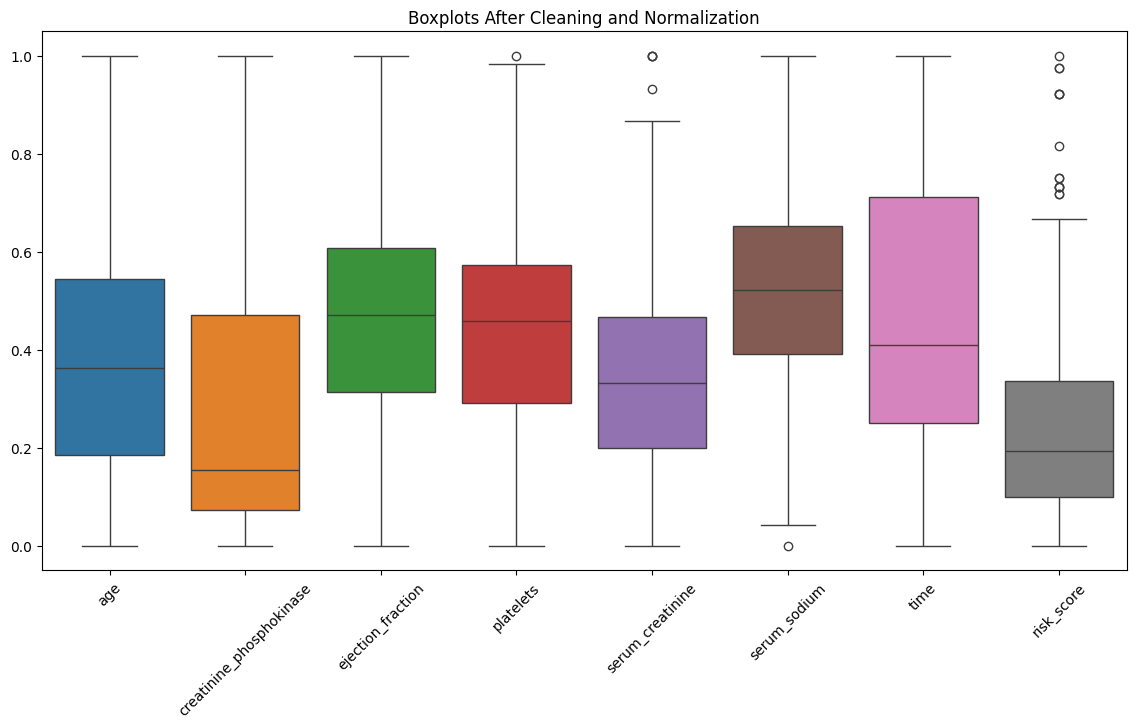

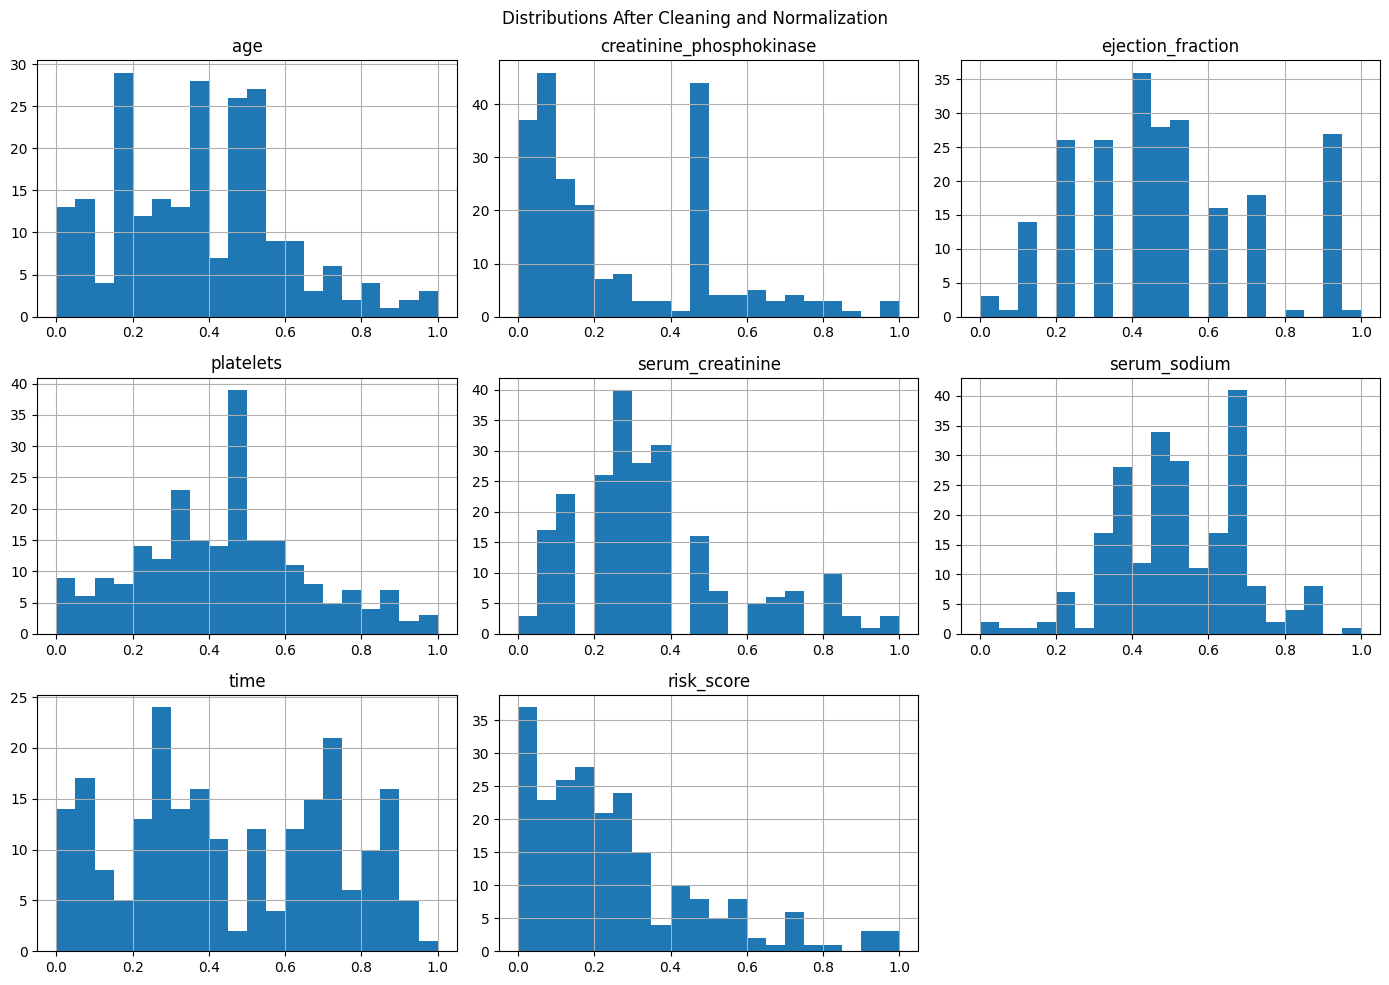

In [ ]:
# ============================================================
# 13. VALIDATE CLEANING
# ============================================================

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df[scale_columns]
)

plt.title("Boxplots After Cleaning and Normalization")

plt.xticks(rotation=45)

plt.show()

df[scale_columns].hist(
    figsize=(14, 10),
    bins=20
)
# histogram
plt.suptitle(
    "Distributions After Cleaning and Normalization"
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# 14. FINAL MISSING VALUE CHECK
# ============================================================

# Make sure all three age-group encoded columns exist
for column in [
    "age_group_<40",
    "age_group_40-60",
    "age_group_>60"
]:
    if column not in df.columns:
        df[column] = 0

print("========== FINAL MISSING VALUE CHECK ==========")

print(df.isnull().sum())

total_missing = df.isnull().sum().sum()

print("\nTotal missing values:", total_missing)

if total_missing == 0:
    print("SUCCESS: No missing values remain.")
else:
    print("Some missing values still remain.")


# ============================================================
# FINAL DATASET
# ============================================================

print("\n========== FINAL DATASET ==========")

print("Final number of rows:", df.shape[0])
print("Final number of columns:", df.shape[1])

print("\nFinal columns:")
print(df.columns.tolist())

display(df.head())


# ============================================================
# SAVE FINAL CLEANED DATASET
# ============================================================

output_file = "heart_failure_cleaned.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nFinal cleaned dataset saved successfully.")
print("File:", output_file)

========== FINAL MISSING VALUE CHECK ==========
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_<40               0
age_group_40-60             0
age_group_>60               0
dtype: int64

Total missing values: 0
SUCCESS: No missing values remain.

========== FINAL DATASET ==========
Final number of rows: 226
Final number of columns: 17

Final columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT', 'risk_score', 'age_group_<40', 'age_group_40-60', 'age_group_>60']


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,0.636364,0,0.470990,0,0.117647,1,0.468852,0.866667,0.217391,1.0,0.0,0.000000,1,0.975,0,0,1
2,0.454545,0,0.098976,0,0.117647,0,0.131148,0.466667,0.173913,1.0,1.0,0.010676,1,0.525,0,0,1
3,0.181818,1,0.069113,0,0.117647,0,0.288525,0.866667,0.521739,1.0,0.0,0.010676,1,0.975,0,1,0
5,0.363636,1,0.014505,0,0.509804,1,0.268852,1.000000,0.304348,1.0,1.0,0.014235,1,0.625,0,1,0
6,0.636364,1,0.184300,0,0.019608,0,0.016393,0.400000,0.521739,1.0,0.0,0.021352,1,0.500,0,0,1



Final cleaned dataset saved successfully.
File: heart_failure_cleaned.csv


In [ ]:
# ============================================================
# SAVE FINAL CLEANED DATASET
# ============================================================

output_file = "heart_failure_cleaned.csv"

df.to_csv(
    output_file,
    index=False
)

print("Final cleaned dataset saved successfully.")
print("File:", output_file)




print("========== FINAL DATASET ==========")

print("Final number of rows:", df.shape[0])
print("Final number of columns:", df.shape[1])

display(df.head())

Final cleaned dataset saved successfully.
File: heart_failure_cleaned.csv
========== FINAL DATASET ==========
Final number of rows: 226
Final number of columns: 17


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,0.636364,0,0.470990,0,0.117647,1,0.468852,0.866667,0.217391,1.0,0.0,0.000000,1,0.975,0,0,1
2,0.454545,0,0.098976,0,0.117647,0,0.131148,0.466667,0.173913,1.0,1.0,0.010676,1,0.525,0,0,1
3,0.181818,1,0.069113,0,0.117647,0,0.288525,0.866667,0.521739,1.0,0.0,0.010676,1,0.975,0,1,0
5,0.363636,1,0.014505,0,0.509804,1,0.268852,1.000000,0.304348,1.0,1.0,0.014235,1,0.625,0,1,0
6,0.636364,1,0.184300,0,0.019608,0,0.016393,0.400000,0.521739,1.0,0.0,0.021352,1,0.500,0,0,1
